In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path   = '/content/drive/MyDrive/ViT-Robustness/results/results_export.zip'
extract_to = '/content/drive/MyDrive/ViT-Robustness/results/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)
print("Unzipped!")

Mounted at /content/drive
Unzipped!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import csv, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

RESULTS_PATH = '/content/drive/MyDrive/ViT-Robustness/results/'
PLOTS_PATH   = RESULTS_PATH + 'plots/'
METRICS_PATH = RESULTS_PATH + 'metrics/'

os.makedirs(PLOTS_PATH, exist_ok=True)

CLASSES = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
results = []
with open(METRICS_PATH + 'accuracy_table.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        results.append(row)

print(f"{'Corruption':<20} {'Severity':<10} {'CNN Acc':<12} {'ViT Acc':<12} {'Gap'}")
print("-" * 60)
for r in results:
    gap = float(r['vit_accuracy']) - float(r['cnn_accuracy'])
    print(f"{r['corruption']:<20} {r['severity']:<10} "
          f"{r['cnn_accuracy']:<12} {r['vit_accuracy']:<12} {gap:+.4f}")

Corruption           Severity   CNN Acc      ViT Acc      Gap
------------------------------------------------------------
gaussian_noise       1          0.2665       0.2182       -0.0483
gaussian_noise       2          0.1318       0.1018       -0.0300
gaussian_noise       3          0.109        0.0998       -0.0092
gaussian_blur        1          0.5395       0.7756       +0.2361
gaussian_blur        2          0.2992       0.3092       +0.0100
gaussian_blur        3          0.2347       0.1635       -0.0712
brightness           1          0.7696       0.9604       +0.1908
brightness           2          0.6195       0.8936       +0.2741
brightness           3          0.1419       0.3028       +0.1609
rotation             1          0.6815       0.9221       +0.2406
rotation             2          0.4614       0.8465       +0.3851
rotation             3          0.3584       0.7219       +0.3635


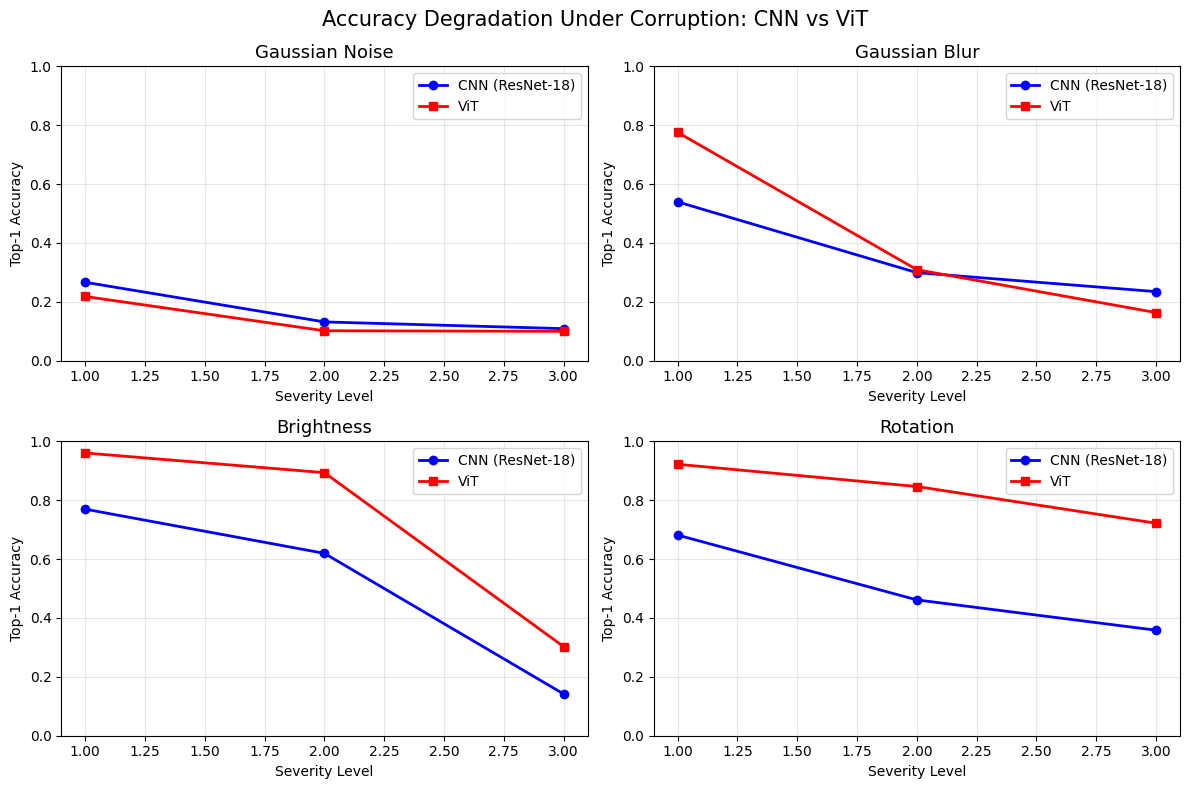

Saved degradation_curves.png


In [4]:
corruptions_list = ['gaussian_noise', 'gaussian_blur', 'brightness', 'rotation']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, corr in enumerate(corruptions_list):
    subset = [r for r in results if r['corruption'] == corr]
    severities = [int(r['severity']) for r in subset]
    cnn_accs   = [float(r['cnn_accuracy']) for r in subset]
    vit_accs   = [float(r['vit_accuracy']) for r in subset]

    axes[idx].plot(severities, cnn_accs, 'b-o', label='CNN (ResNet-18)', linewidth=2)
    axes[idx].plot(severities, vit_accs, 'r-s', label='ViT', linewidth=2)
    axes[idx].set_title(corr.replace('_', ' ').title(), fontsize=13)
    axes[idx].set_xlabel('Severity Level')
    axes[idx].set_ylabel('Top-1 Accuracy')
    axes[idx].legend()
    axes[idx].set_ylim(0, 1)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Accuracy Degradation Under Corruption: CNN vs ViT', fontsize=15)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved degradation_curves.png")

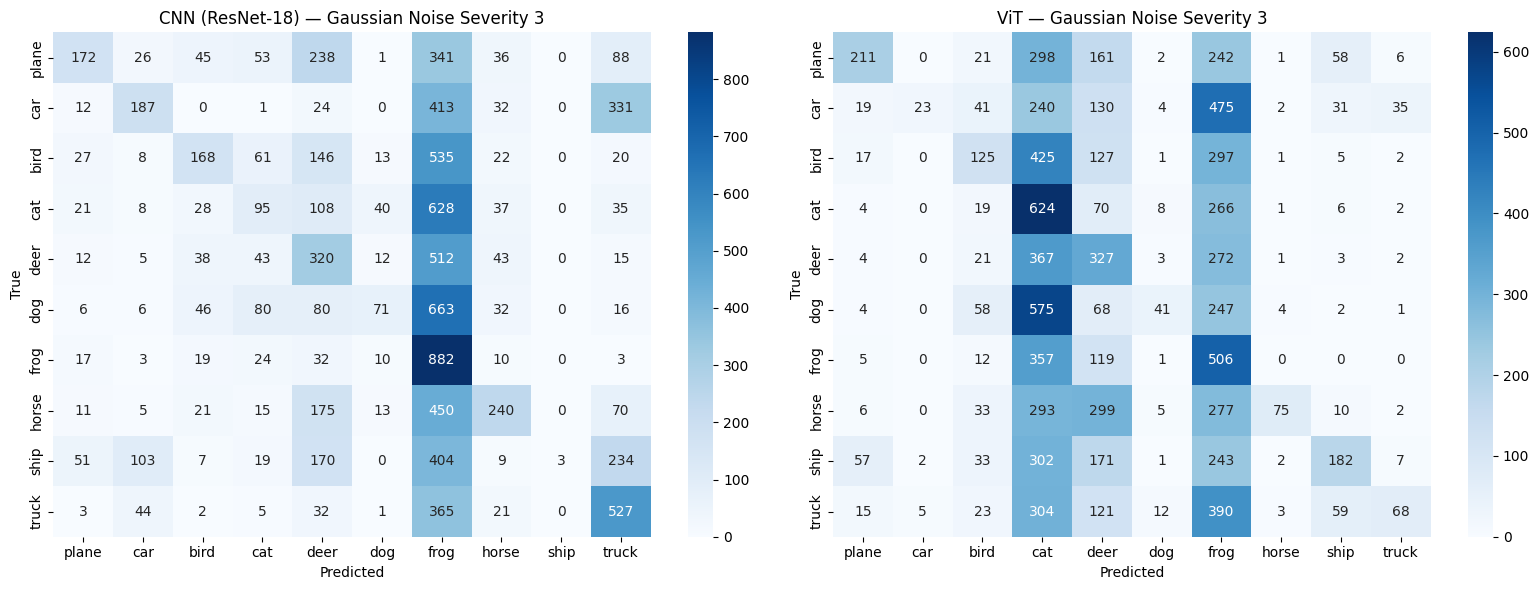

Saved confusion_matrices.png


In [5]:
# Load predictions for worst corruption (severity level 3, gaussian noise as example)
cnn_preds = np.load(METRICS_PATH + 'cnn_preds_gaussian_noise_s1.npy')
vit_preds = np.load(METRICS_PATH + 'vit_preds_gaussian_noise_s1.npy')
true_labels = np.load(METRICS_PATH + 'true_labels.npy')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in zip(axes, [cnn_preds, vit_preds], ['CNN (ResNet-18)', 'ViT']):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'{title} — Gaussian Noise Severity 3', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(PLOTS_PATH + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png")

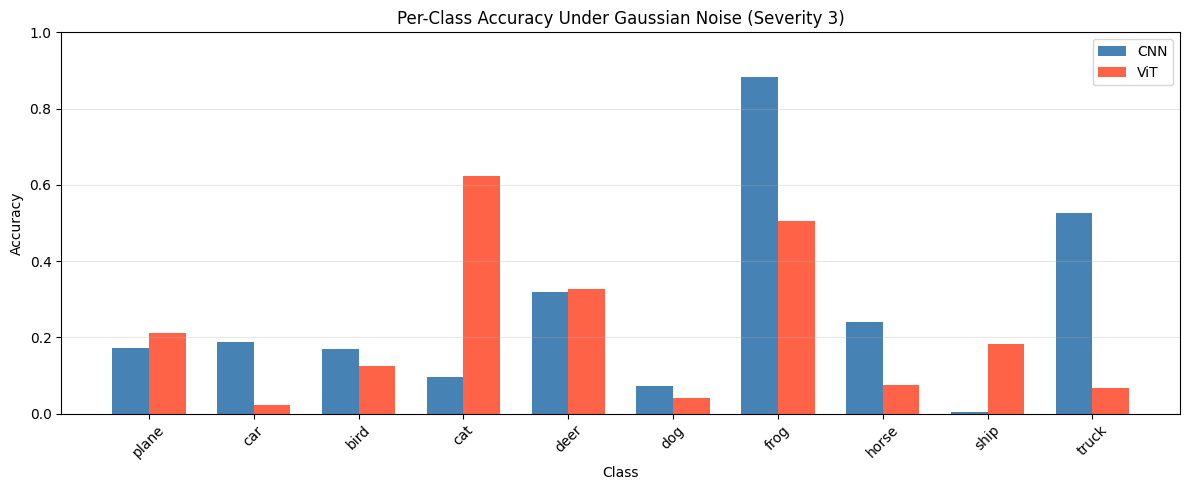

Saved per_class_accuracy.png


In [6]:
# Compare clean vs worst corruption per class
# You'll need clean predictions saved too — add a "clean" evaluation row in Notebook 3

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASSES))
width = 0.35

# Calculate per-class accuracy
def per_class_acc(preds, labels):
    accs = []
    for c in range(10):
        mask = np.array(labels) == c
        if mask.sum() == 0:
            accs.append(0)
        else:
            accs.append((np.array(preds)[mask] == c).mean())
    return accs

cnn_class_acc = per_class_acc(cnn_preds, true_labels)
vit_class_acc = per_class_acc(vit_preds, true_labels)

bars1 = ax.bar(x - width/2, cnn_class_acc, width, label='CNN', color='steelblue')
bars2 = ax.bar(x + width/2, vit_class_acc, width, label='ViT', color='tomato')

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy Under Gaussian Noise (Severity 3)')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_PATH + 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_class_accuracy.png")

In [7]:
# We need clean accuracy numbers to compare against
# Since we don't have clean predictions saved, we calculate from the CSV
print("Corruption Results Summary:")
print(f"{'Corruption':<20} {'Sev':<5} {'CNN':>8} {'ViT':>8} {'Gap':>8}")
print("-" * 55)
for r in results:
    gap = float(r['vit_accuracy']) - float(r['cnn_accuracy'])
    print(f"{r['corruption']:<20} {r['severity']:<5} "
          f"{float(r['cnn_accuracy']):>8.1%} {float(r['vit_accuracy']):>8.1%} "
          f"{gap:>+8.1%}")

Corruption Results Summary:
Corruption           Sev        CNN      ViT      Gap
-------------------------------------------------------
gaussian_noise       1        26.7%    21.8%    -4.8%
gaussian_noise       2        13.2%    10.2%    -3.0%
gaussian_noise       3        10.9%    10.0%    -0.9%
gaussian_blur        1        53.9%    77.6%   +23.6%
gaussian_blur        2        29.9%    30.9%    +1.0%
gaussian_blur        3        23.5%    16.4%    -7.1%
brightness           1        77.0%    96.0%   +19.1%
brightness           2        62.0%    89.4%   +27.4%
brightness           3        14.2%    30.3%   +16.1%
rotation             1        68.2%    92.2%   +24.1%
rotation             2        46.1%    84.7%   +38.5%
rotation             3        35.8%    72.2%   +36.4%


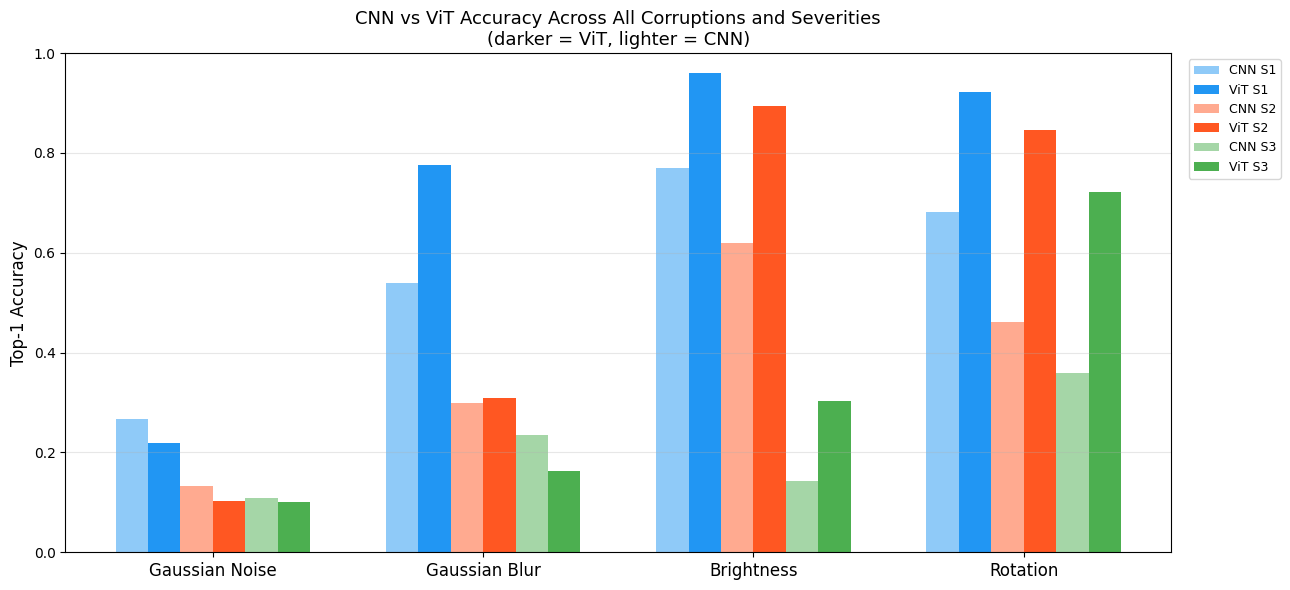

Saved robustness_comparison.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

corruptions_list = ['gaussian_noise', 'gaussian_blur', 'brightness', 'rotation']
severity_labels  = ['S1', 'S2', 'S3']
colors = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(13, 6))

x       = np.arange(len(corruptions_list))
n_sev   = 3
width   = 0.12
offsets = np.linspace(-(n_sev-1)/2, (n_sev-1)/2, n_sev) * width * 2

for sev_idx in range(n_sev):
    cnn_accs, vit_accs, gaps = [], [], []
    for corr in corruptions_list:
        row = next(r for r in results
                   if r['corruption'] == corr and int(r['severity']) == sev_idx+1)
        cnn_accs.append(float(row['cnn_accuracy']))
        vit_accs.append(float(row['vit_accuracy']))
        gaps.append(float(row['vit_accuracy']) - float(row['cnn_accuracy']))

    ax.bar(x + offsets[sev_idx] - width/2, cnn_accs, width,
           label=f'CNN S{sev_idx+1}', color=colors[sev_idx], alpha=0.5)
    ax.bar(x + offsets[sev_idx] + width/2, vit_accs, width,
           label=f'ViT S{sev_idx+1}', color=colors[sev_idx], alpha=1.0)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ').title() for c in corruptions_list], fontsize=12)
ax.set_ylabel('Top-1 Accuracy', fontsize=12)
ax.set_title('CNN vs ViT Accuracy Across All Corruptions and Severities\n(darker = ViT, lighter = CNN)', fontsize=13)
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'robustness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved robustness_comparison.png")

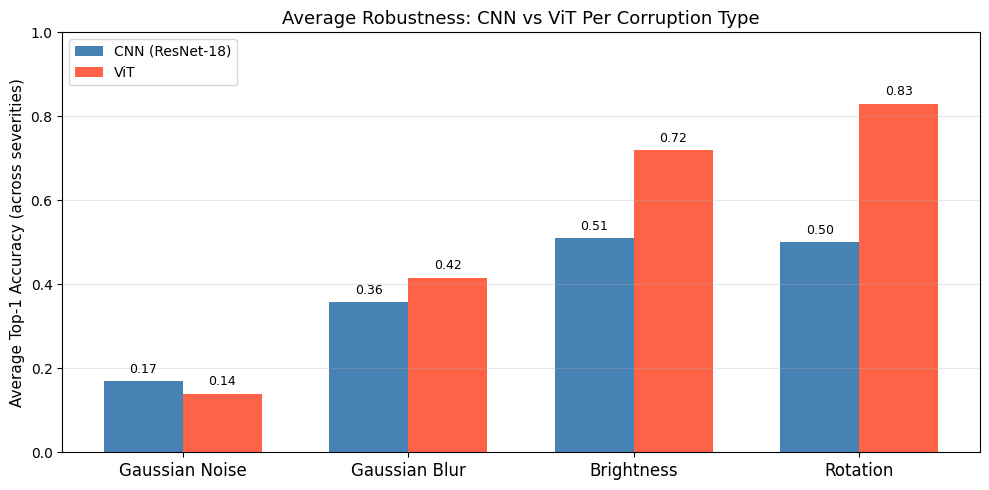

Saved average_robustness.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

corr_labels, cnn_means, vit_means = [], [], []
for corr in corruptions_list:
    subset = [r for r in results if r['corruption'] == corr]
    cnn_means.append(np.mean([float(r['cnn_accuracy']) for r in subset]))
    vit_means.append(np.mean([float(r['vit_accuracy']) for r in subset]))
    corr_labels.append(corr.replace('_', ' ').title())

x     = np.arange(len(corr_labels))
width = 0.35
ax.bar(x - width/2, cnn_means, width, label='CNN (ResNet-18)', color='steelblue')
ax.bar(x + width/2, vit_means, width, label='ViT',             color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(corr_labels, fontsize=12)
ax.set_ylabel('Average Top-1 Accuracy (across severities)', fontsize=11)
ax.set_title('Average Robustness: CNN vs ViT Per Corruption Type', fontsize=13)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for i, (c, v) in enumerate(zip(cnn_means, vit_means)):
    ax.text(i - width/2, c + 0.02, f'{c:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_PATH + 'average_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved average_robustness.png")